# 02 — Business EDA: Customer Risk Segmentation and Affordability Analysis

## Objective

This notebook explores repayment difficulty from a business and credit-risk perspective.

The goal is not only to describe the dataset, but to identify customer segments and financial indicators that are associated with higher repayment risk.

This analysis focuses on four business questions:

1. Which customer segments show higher repayment-difficulty rates?
2. Do affordability indicators help explain repayment risk?
3. How does repayment risk vary by age and employment profile?
4. Do external credit-score variables separate low-risk and high-risk applicants?

## Why This Matters

For a lender, predicting repayment difficulty is only useful if the analysis can support better lending decisions.

This notebook will help translate raw applicant data into business insights that can later support:

- underwriting strategy
- risk segmentation
- feature engineering
- model development
- approve / review / decline decision design

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

train_path = RAW_DATA_DIR / "application_train.csv"

train = pd.read_csv(train_path)

print("Data loaded successfully.")
print("Shape:", train.shape)
print("Project root:", PROJECT_ROOT)

Data loaded successfully.
Shape: (307511, 122)
Project root: /Users/hxxy/Desktop/找工/credit-risk-decisioning


In [2]:
eda = train.copy()

eda["AGE_YEARS"] = -eda["DAYS_BIRTH"] / 365.25

eda["EMPLOYMENT_YEARS"] = np.where(
    eda["DAYS_EMPLOYED"] == 365243,
    np.nan,
    -eda["DAYS_EMPLOYED"] / 365.25
)

eda["CREDIT_INCOME_RATIO"] = (
    eda["AMT_CREDIT"] / eda["AMT_INCOME_TOTAL"]
)

eda["ANNUITY_INCOME_RATIO"] = (
    eda["AMT_ANNUITY"] / eda["AMT_INCOME_TOTAL"]
)

eda["CREDIT_TERM_PROXY"] = (
    eda["AMT_CREDIT"] / eda["AMT_ANNUITY"]
)

eda[
    [
        "AGE_YEARS",
        "EMPLOYMENT_YEARS",
        "CREDIT_INCOME_RATIO",
        "ANNUITY_INCOME_RATIO",
        "CREDIT_TERM_PROXY"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
AGE_YEARS,"307,511.00",43.91,11.95,20.50,33.98,43.12,53.89,69.07
EMPLOYMENT_YEARS,"252,137.00",6.53,6.40,0.00,2.10,4.51,8.69,49.04
CREDIT_INCOME_RATIO,"307,511.00",3.96,2.69,0.00,2.02,3.27,5.16,84.74
ANNUITY_INCOME_RATIO,"307,499.00",0.18,0.09,0.00,0.11,0.16,0.23,1.88
CREDIT_TERM_PROXY,"307,499.00",21.61,7.82,8.04,15.61,20.00,27.10,45.31


## Derived Business Features

To make the analysis more meaningful from a credit-risk perspective, several raw fields were converted into business-friendly features.

- `AGE_YEARS` converts applicant age from days into years.
- `EMPLOYMENT_YEARS` converts employment duration into years, after treating the artificial placeholder value `365243` as missing.
- `CREDIT_INCOME_RATIO` measures total credit amount relative to income.
- `ANNUITY_INCOME_RATIO` measures annual repayment burden relative to income.
- `CREDIT_TERM_PROXY` approximates the repayment term by comparing credit amount with annuity amount.

These features are easier to interpret than the original raw variables and will be used to analyze repayment risk across customer groups.

## Portfolio Overview

This section summarizes the overall application portfolio, including total application volume, repayment-difficulty rate, and typical financial characteristics.

This provides a baseline understanding before comparing risk across customer segments.

In [4]:
portfolio_summary = pd.DataFrame({
    "metric": [
        "Total applications",
        "Repayment difficulty cases",
        "Repayment difficulty rate",
        "Median income",
        "Median credit amount",
        "Median annuity",
        "Median annuity-to-income ratio"
    ],
    "value": [
        len(eda),
        eda["TARGET"].sum(),
        eda["TARGET"].mean(),
        eda["AMT_INCOME_TOTAL"].median(),
        eda["AMT_CREDIT"].median(),
        eda["AMT_ANNUITY"].median(),
        eda["ANNUITY_INCOME_RATIO"].median()
    ]
})

portfolio_summary

,metric,value
0,Total applications,"307,511.00"
1,Repayment difficulty cases,"24,825.00"
2,Repayment difficulty rate,0.08
3,Median income,"147,150.00"
4,Median credit amount,"513,531.00"
5,Median annuity,"24,903.00"
6,Median annuity-to-income ratio,0.16


### Interpretation

The portfolio contains more than 300,000 loan applications, with approximately 8% of applicants experiencing repayment difficulty.

This indicates that repayment difficulty is a relatively rare event in the portfolio. As a result, later analysis should focus on repayment-difficulty rates rather than raw counts alone.

The median applicant has an annual income of about 147K, a credit amount of about 514K, and an annuity-to-income ratio of about 16%. This provides a baseline for evaluating whether certain customer groups face higher repayment burden or higher credit risk.

## Target Distribution

Before analyzing customer segments, we first check the distribution of the target variable.

In this project:

- `TARGET = 0` means the applicant did not experience repayment difficulty.
- `TARGET = 1` means the applicant experienced repayment difficulty.

This helps us understand how common the risk event is in the portfolio.

In [5]:
target_summary = (
    eda["TARGET"]
    .value_counts()
    .sort_index()
    .to_frame("applications")
)

target_summary["percentage"] = (
    target_summary["applications"] / len(eda) * 100
)

target_summary

,applications,percentage
TARGET,,
0,282686,91.93
1,24825,8.07


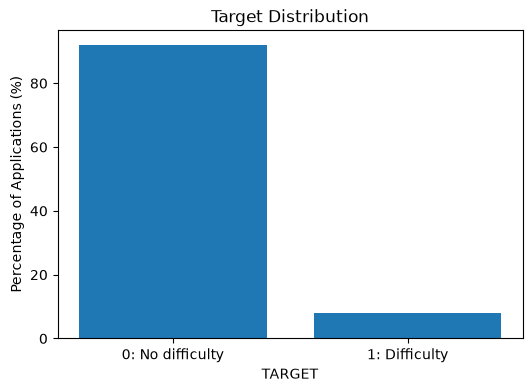

In [6]:
plt.figure(figsize=(6, 4))

plt.bar(
    target_summary.index.astype(str),
    target_summary["percentage"]
)

plt.title("Target Distribution")
plt.xlabel("TARGET")
plt.ylabel("Percentage of Applications (%)")
plt.xticks(
    ticks=[0, 1],
    labels=["0: No difficulty", "1: Difficulty"]
)

plt.show()

### Interpretation

The majority of applicants did not experience repayment difficulty, while only about 8% of applicants belong to the repayment-difficulty group.

This confirms that the target variable is highly imbalanced. From a business perspective, this is expected because serious repayment difficulty is usually a relatively rare event in a lending portfolio.

For later modeling, accuracy alone will not be a reliable evaluation metric. A model could achieve high accuracy by predicting most applicants as low risk. Therefore, later analysis should also consider metrics such as recall, precision, ROC-AUC, PR-AUC, and threshold-based approval/default trade-offs.

## Customer Segment Risk by Income Type

This section compares repayment-difficulty rates across different income types.

Instead of only looking at the number of applicants in each group, we focus on the repayment-difficulty rate, because some groups may be large but relatively low risk, while smaller groups may have higher risk.

In [7]:
def segment_risk_summary(data, column, min_count=500):
    summary = (
        data.groupby(column, dropna=False)
        .agg(
            applications=("SK_ID_CURR", "count"),
            repayment_difficulty_cases=("TARGET", "sum"),
            repayment_difficulty_rate=("TARGET", "mean")
        )
        .reset_index()
    )

    summary = summary[
        summary["applications"] >= min_count
    ].copy()

    summary["repayment_difficulty_rate_pct"] = (
        summary["repayment_difficulty_rate"] * 100
    )

    return summary.sort_values(
        "repayment_difficulty_rate_pct",
        ascending=False
    )

In [8]:
income_type_risk = segment_risk_summary(
    eda,
    "NAME_INCOME_TYPE"
)

income_type_risk

,NAME_INCOME_TYPE,applications,repayment_difficulty_cases,repayment_difficulty_rate,repayment_difficulty_rate_pct
7,Working,158774,15224,0.10,9.59
1,Commercial associate,71617,5360,0.07,7.48
4,State servant,21703,1249,0.06,5.75
3,Pensioner,55362,2982,0.05,5.39


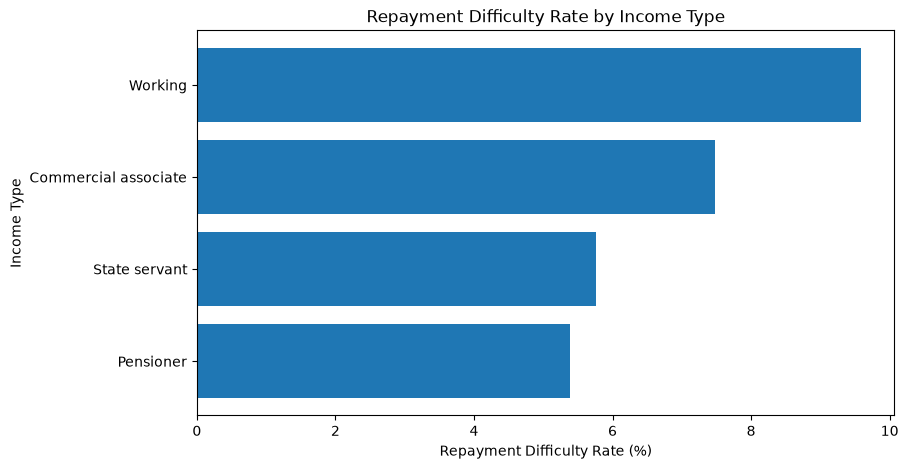

In [9]:
plt.figure(figsize=(9, 5))

plt.barh(
    income_type_risk["NAME_INCOME_TYPE"],
    income_type_risk["repayment_difficulty_rate_pct"]
)

plt.title("Repayment Difficulty Rate by Income Type")
plt.xlabel("Repayment Difficulty Rate (%)")
plt.ylabel("Income Type")
plt.gca().invert_yaxis()

plt.show()

### Interpretation

Repayment-difficulty rates vary meaningfully across income types.

Applicants classified as `Working` show the highest repayment-difficulty rate among the major income groups, followed by `Commercial associate`. In contrast, `State servant` and `Pensioner` applicants show lower repayment-difficulty rates.

From a credit-risk perspective, income type may capture differences in income stability, employment protection, and financial resilience. However, this result is descriptive rather than causal. Income type should be treated as one segmentation signal and interpreted together with other variables such as income level, age, employment history, and external credit scores.

## Customer Segment Risk by Education Type

This section compares repayment-difficulty rates across education levels.

Education may be associated with income potential, employment stability, and access to financial resources. However, the analysis is descriptive and should not be interpreted as a causal relationship.

In [10]:
education_risk = segment_risk_summary(
    eda,
    "NAME_EDUCATION_TYPE"
)

education_risk

,NAME_EDUCATION_TYPE,applications,repayment_difficulty_cases,repayment_difficulty_rate,repayment_difficulty_rate_pct
3,Lower secondary,3816,417,0.11,10.93
4,Secondary / secondary special,218391,19524,0.09,8.94
2,Incomplete higher,10277,872,0.08,8.48
1,Higher education,74863,4009,0.05,5.36


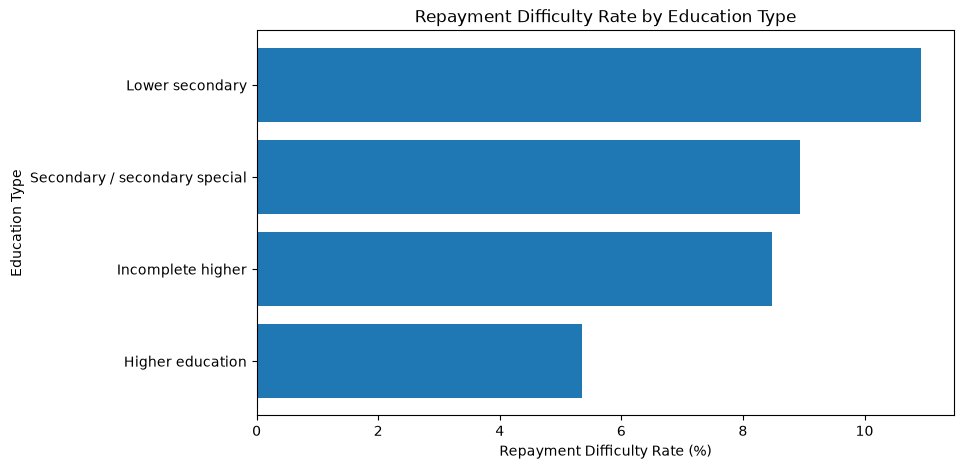

In [11]:
plt.figure(figsize=(9, 5))

plt.barh(
    education_risk["NAME_EDUCATION_TYPE"],
    education_risk["repayment_difficulty_rate_pct"]
)

plt.title("Repayment Difficulty Rate by Education Type")
plt.xlabel("Repayment Difficulty Rate (%)")
plt.ylabel("Education Type")
plt.gca().invert_yaxis()

plt.show()

### Interpretation

Repayment-difficulty rates differ across education levels. Applicants with `Lower secondary` education show the highest repayment-difficulty rate, while applicants with `Higher education` show the lowest rate.

From a credit-risk perspective, education level may be associated with income potential, employment stability, financial literacy, and access to more stable job opportunities. However, this relationship is descriptive rather than causal. Education should be interpreted together with income, occupation, age, and external credit-score variables.

## Customer Segment Risk by Age Group

This section compares repayment-difficulty rates across applicant age groups.

Age may be related to credit history length, income stability, savings, and financial experience. The goal is to understand whether repayment risk varies across different life stages.

In [12]:
eda["AGE_GROUP"] = pd.cut(
    eda["AGE_YEARS"],
    bins=[20, 30, 40, 50, 60, 70],
    right=False,
    labels=[
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69"
    ]
)

age_risk = (
    eda.groupby("AGE_GROUP", observed=True)
    .agg(
        applications=("SK_ID_CURR", "count"),
        repayment_difficulty_cases=("TARGET", "sum"),
        repayment_difficulty_rate=("TARGET", "mean")
    )
    .reset_index()
)

age_risk["repayment_difficulty_rate_pct"] = (
    age_risk["repayment_difficulty_rate"] * 100
)

age_risk

,AGE_GROUP,applications,repayment_difficulty_cases,repayment_difficulty_rate,repayment_difficulty_rate_pct
0,20-29,45186,5171,0.11,11.44
1,30-39,82331,7897,0.10,9.59
2,40-49,76599,5853,0.08,7.64
3,50-59,68094,4168,0.06,6.12
4,60-69,35301,1736,0.05,4.92


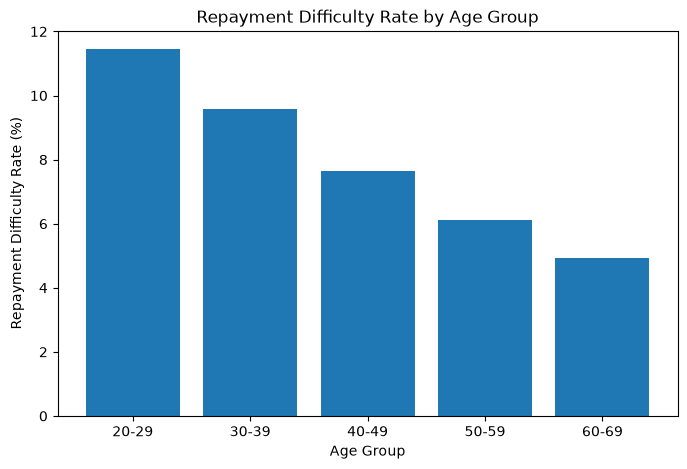

In [13]:
plt.figure(figsize=(8, 5))

plt.bar(
    age_risk["AGE_GROUP"].astype(str),
    age_risk["repayment_difficulty_rate_pct"]
)

plt.title("Repayment Difficulty Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Repayment Difficulty Rate (%)")

plt.show()

### Interpretation

Repayment-difficulty rates decline steadily as applicant age increases.

Applicants in the 20–29 age group show the highest repayment-difficulty rate, while applicants in older age groups show lower rates. This suggests that age may be an important risk-segmentation variable.

From a credit-risk perspective, younger applicants may have shorter credit histories, lower accumulated savings, less stable employment, or thinner financial buffers. However, age itself should not be interpreted as the direct cause of repayment difficulty. It should be evaluated together with income, employment history, affordability indicators, and external credit-score variables.

## Affordability Analysis

This section analyzes whether repayment burden is associated with repayment difficulty.

Instead of only looking at income or credit amount separately, we use affordability ratios to measure how large the repayment obligation is relative to the applicant's income.

The main variable used here is:

- `ANNUITY_INCOME_RATIO`: annual annuity amount divided by total income

A higher annuity-to-income ratio means the applicant needs to use a larger share of income to cover repayment.

In [14]:
eda["ANNUITY_INCOME_DECILE"] = pd.qcut(
    eda["ANNUITY_INCOME_RATIO"],
    q=10,
    duplicates="drop"
)

affordability_risk = (
    eda.groupby("ANNUITY_INCOME_DECILE", observed=True)
    .agg(
        applications=("SK_ID_CURR", "count"),
        repayment_difficulty_cases=("TARGET", "sum"),
        repayment_difficulty_rate=("TARGET", "mean"),
        median_annuity_income_ratio=("ANNUITY_INCOME_RATIO", "median")
    )
    .reset_index()
)

affordability_risk["repayment_difficulty_rate_pct"] = (
    affordability_risk["repayment_difficulty_rate"] * 100
)

affordability_risk

,ANNUITY_INCOME_DECILE,applications,repayment_difficulty_cases,repayment_difficulty_rate,median_annuity_income_ratio,repayment_difficulty_rate_pct
0,"(-0.000776, 0.08]",31645,2258,0.07,0.06,7.14
1,"(0.08, 0.104]",29855,2168,0.07,0.09,7.26
2,"(0.104, 0.125]",30757,2405,0.08,0.11,7.82
3,"(0.125, 0.144]",30750,2412,0.08,0.13,7.84
4,"(0.144, 0.163]",30757,2423,0.08,0.15,7.88
5,"(0.163, 0.186]",30737,2574,0.08,0.17,8.37
6,"(0.186, 0.212]",30768,2627,0.09,0.20,8.54
7,"(0.212, 0.247]",30754,2723,0.09,0.23,8.85
8,"(0.247, 0.302]",30726,2716,0.09,0.27,8.84
9,"(0.302, 1.876]",30750,2519,0.08,0.35,8.19


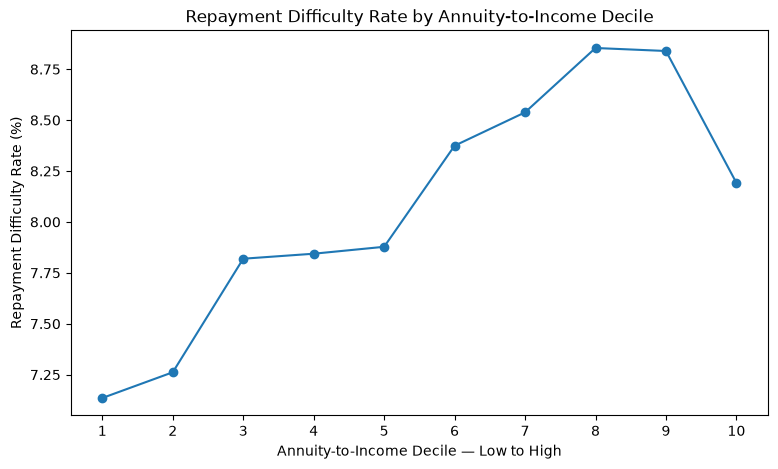

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(affordability_risk) + 1),
    affordability_risk["repayment_difficulty_rate_pct"],
    marker="o"
)

plt.title("Repayment Difficulty Rate by Annuity-to-Income Decile")
plt.xlabel("Annuity-to-Income Decile — Low to High")
plt.ylabel("Repayment Difficulty Rate (%)")
plt.xticks(range(1, len(affordability_risk) + 1))

plt.show()

### Interpretation

Repayment-difficulty rates generally increase as the annuity-to-income ratio rises from lower to higher deciles.

This suggests that repayment burden is associated with credit risk. Applicants who need to use a larger share of their income to cover loan payments tend to show higher repayment-difficulty rates.

However, the relationship is not perfectly linear. The highest decile does not continue to increase, which suggests that affordability risk should not be interpreted using this ratio alone. It may interact with other factors such as income level, age, contract type, employment stability, and external credit scores.

From a lending perspective, `ANNUITY_INCOME_RATIO` is still a useful affordability indicator and should be considered as a candidate feature for downstream modeling and decision analysis.

## External Credit Score Analysis

This section analyzes external credit-score variables.

The dataset includes three external score variables:

- `EXT_SOURCE_1`
- `EXT_SOURCE_2`
- `EXT_SOURCE_3`

These variables can be interpreted as external risk scores or third-party credit-related signals. If they are useful, applicants with lower scores should show higher repayment-difficulty rates.

In [16]:
external_score_summary = (
    eda.groupby("TARGET")[
        ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    ]
    .median()
    .T
)

external_score_summary.columns = [
    "No repayment difficulty",
    "Repayment difficulty"
]

external_score_summary

,No repayment difficulty,Repayment difficulty
EXT_SOURCE_1,0.52,0.36
EXT_SOURCE_2,0.57,0.44
EXT_SOURCE_3,0.55,0.38


### Interpretation

Applicants with repayment difficulty have noticeably lower median external scores across all three external-score variables.

This suggests that `EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3` provide meaningful risk separation between lower-risk and higher-risk applicants.

From a credit-risk perspective, these variables are likely to be important predictors in downstream modeling because they summarize external credit-related signals that are not fully captured by income, age, or employment variables alone.

In [ ]:
eda["EXT_SOURCE_2_DECILE"] = pd.qcut(
    eda["EXT_SOURCE_2"],
    q=10,
    duplicates="drop"
)

ext_source_2_risk = (
    eda.groupby("EXT_SOURCE_2_DECILE", observed=True)
    .agg(
        applications=("SK_ID_CURR", "count"),
        repayment_difficulty_cases=("TARGET", "sum"),
        repayment_difficulty_rate=("TARGET", "mean"),
        median_ext_source_2=("EXT_SOURCE_2", "median")
    )
    .reset_index()
)

ext_source_2_risk["repayment_difficulty_rate_pct"] = (
    ext_source_2_risk["repayment_difficulty_rate"] * 100
)

ext_source_2_risk

,EXT_SOURCE_2_DECILE,applications,repayment_difficulty_cases,repayment_difficulty_rate,median_ext_source_2,repayment_difficulty_rate_pct
0,"(-0.0009999183, 0.216]",30686,5631,0.18,0.13,18.35
1,"(0.216, 0.34]",30685,3706,0.12,0.28,12.08
2,"(0.34, 0.44]",30687,3056,0.10,0.39,9.96
3,"(0.44, 0.512]",30684,2566,0.08,0.48,8.36
4,"(0.512, 0.566]",30684,2278,0.07,0.54,7.42
5,"(0.566, 0.608]",30687,2042,0.07,0.59,6.65
6,"(0.608, 0.646]",30683,1794,0.06,0.63,5.85
7,"(0.646, 0.682]",30694,1499,0.05,0.66,4.88
8,"(0.682, 0.722]",30676,1289,0.04,0.70,4.20
9,"(0.722, 0.855]",30685,912,0.03,0.75,2.97


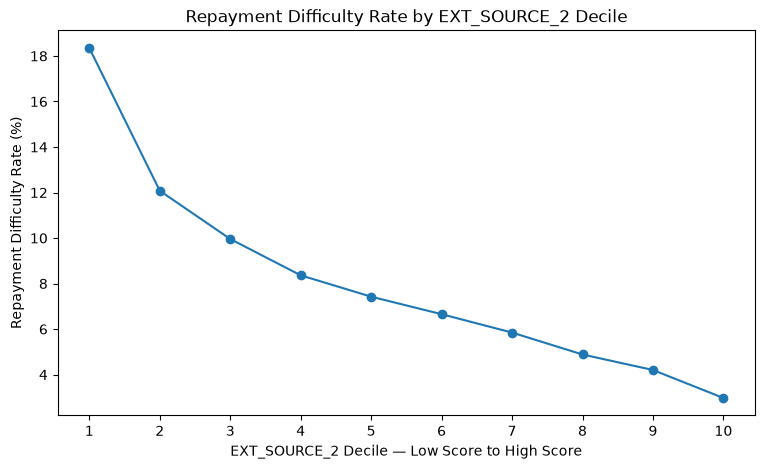

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(ext_source_2_risk) + 1),
    ext_source_2_risk["repayment_difficulty_rate_pct"],
    marker="o"
)

plt.title("Repayment Difficulty Rate by EXT_SOURCE_2 Decile")
plt.xlabel("EXT_SOURCE_2 Decile — Low Score to High Score")
plt.ylabel("Repayment Difficulty Rate (%)")
plt.xticks(range(1, len(ext_source_2_risk) + 1))

plt.show()

### Interpretation

Repayment-difficulty rates decline sharply as `EXT_SOURCE_2` increases.

Applicants in the lowest `EXT_SOURCE_2` decile show the highest repayment-difficulty rate, while applicants in the highest decile show the lowest repayment-difficulty rate. This creates a clear monotonic risk pattern.

From a credit-risk perspective, this suggests that `EXT_SOURCE_2` provides strong risk separation and is likely to be one of the most important variables for downstream modeling.

Compared with demographic or affordability variables, `EXT_SOURCE_2` appears to capture broader external credit-related information and can help distinguish higher-risk applicants from lower-risk applicants more effectively.

## Key Findings

This business EDA identified several important repayment-risk patterns in the application portfolio.

1. **Repayment difficulty is a relatively rare event.**  
   Around 8% of applicants experienced repayment difficulty. This means the target variable is imbalanced, and later modeling should not rely on accuracy alone.

2. **Income type is associated with repayment risk.**  
   Applicants classified as `Working` show the highest repayment-difficulty rate among the major income groups, while `State servant` and `Pensioner` applicants show lower rates. This suggests that income stability may be an important segmentation factor.

3. **Education level shows meaningful risk differences.**  
   Applicants with lower education levels show higher repayment-difficulty rates, while applicants with higher education show lower rates. This relationship may reflect differences in income potential, employment stability, and financial resilience.

4. **Younger applicants show higher repayment-difficulty rates.**  
   Repayment-difficulty rates decline steadily as applicant age increases. Age may capture differences in credit history length, savings, employment stability, and financial experience.

5. **Affordability pressure is associated with repayment risk.**  
   Repayment-difficulty rates generally rise as the annuity-to-income ratio increases. This suggests that repayment burden is a useful risk indicator, although the relationship is not perfectly linear.

6. **External credit-score variables provide strong risk separation.**  
   Applicants with repayment difficulty have noticeably lower external scores. In particular, `EXT_SOURCE_2` shows a clear monotonic pattern: lower score deciles have much higher repayment-difficulty rates, while higher score deciles have much lower rates.

## Business Implications

The analysis suggests that repayment risk is not driven by a single factor. Instead, it is associated with a combination of applicant profile, affordability, and external credit signals.

For downstream modeling, the most important candidate variables include:

- `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`
- `AGE_YEARS`
- `NAME_INCOME_TYPE`
- `NAME_EDUCATION_TYPE`
- `ANNUITY_INCOME_RATIO`
- `CREDIT_INCOME_RATIO`
- `EMPLOYMENT_YEARS`

These findings will guide feature engineering, model development, and later approve / review / decline decision analysis.